# Face-aware crop vs. centre crop

`face_aware_crop` (`src/lib/crop.py`) does a resize-to-cover, then biases the
crop toward the joint span of the head-extended face boxes. For portrait
sources rendered onto a landscape target, the face centre lands on the **top
third** of the crop window instead of the middle, so the eyes sit on the
upper-third line where landscape composition reads best.

The notebook walks each bundled photo through both target orientations
(800x480 landscape and 480x800 portrait) and shows:

1. Original with face boxes drawn (cyan = head-extended, yellow = raw box)
2. Naive centre cover-crop (no face awareness)
3. `face_aware_crop` output

The pool comes from the bundled CC photos in `photos/`.

In [1]:
import sys

sys.path.insert(0, ".")
from _helpers import (
    bootstrap,
    center_crop,
    image_faces,
    local_pool,
    open_image,
)

bootstrap()

import matplotlib.pyplot as plt
from crop import HEAD_EXTENSION, face_aware_crop
from PIL import ImageDraw

LANDSCAPE = (800, 480)
PORTRAIT = (480, 800)

In [2]:
pool = local_pool()
with_faces = [a for a in pool if image_faces(a)]
print(f"pool: {len(pool)} photos, {len(with_faces)} with faces")
for a in with_faces:
    w, h = a["exifInfo"]["exifImageWidth"], a["exifInfo"]["exifImageHeight"]
    orient = "portrait" if h > w else "landscape"
    print(f"  {a['originalFileName']:35s} {w}x{h} ({orient})")

pool: 6 photos, 3 with faces
  man_on_cliff.jpg                    1600x1067 (landscape)
  man_with_dog.jpg                    1600x1067 (landscape)
  mother_and_daughter.jpg             800x1200 (portrait)


In [3]:
def draw_face_boxes(image, faces):
    """Copy of image with face boxes overlaid (cyan = head-extended, yellow = raw)."""
    iw, ih = image.size
    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)
    line_w = max(2, min(iw, ih) // 250)
    for f in faces:
        sx = iw / (f.get("imageWidth") or iw)
        sy = ih / (f.get("imageHeight") or ih)
        x1, y1 = f["boundingBoxX1"] * sx, f["boundingBoxY1"] * sy
        x2, y2 = f["boundingBoxX2"] * sx, f["boundingBoxY2"] * sy
        head_y1 = y1 - (y2 - y1) * HEAD_EXTENSION
        draw.rectangle([x1, head_y1, x2, y2], outline=(0, 220, 255), width=line_w)
        draw.rectangle([x1, y1, x2, y2], outline=(255, 220, 0), width=line_w)
    return canvas

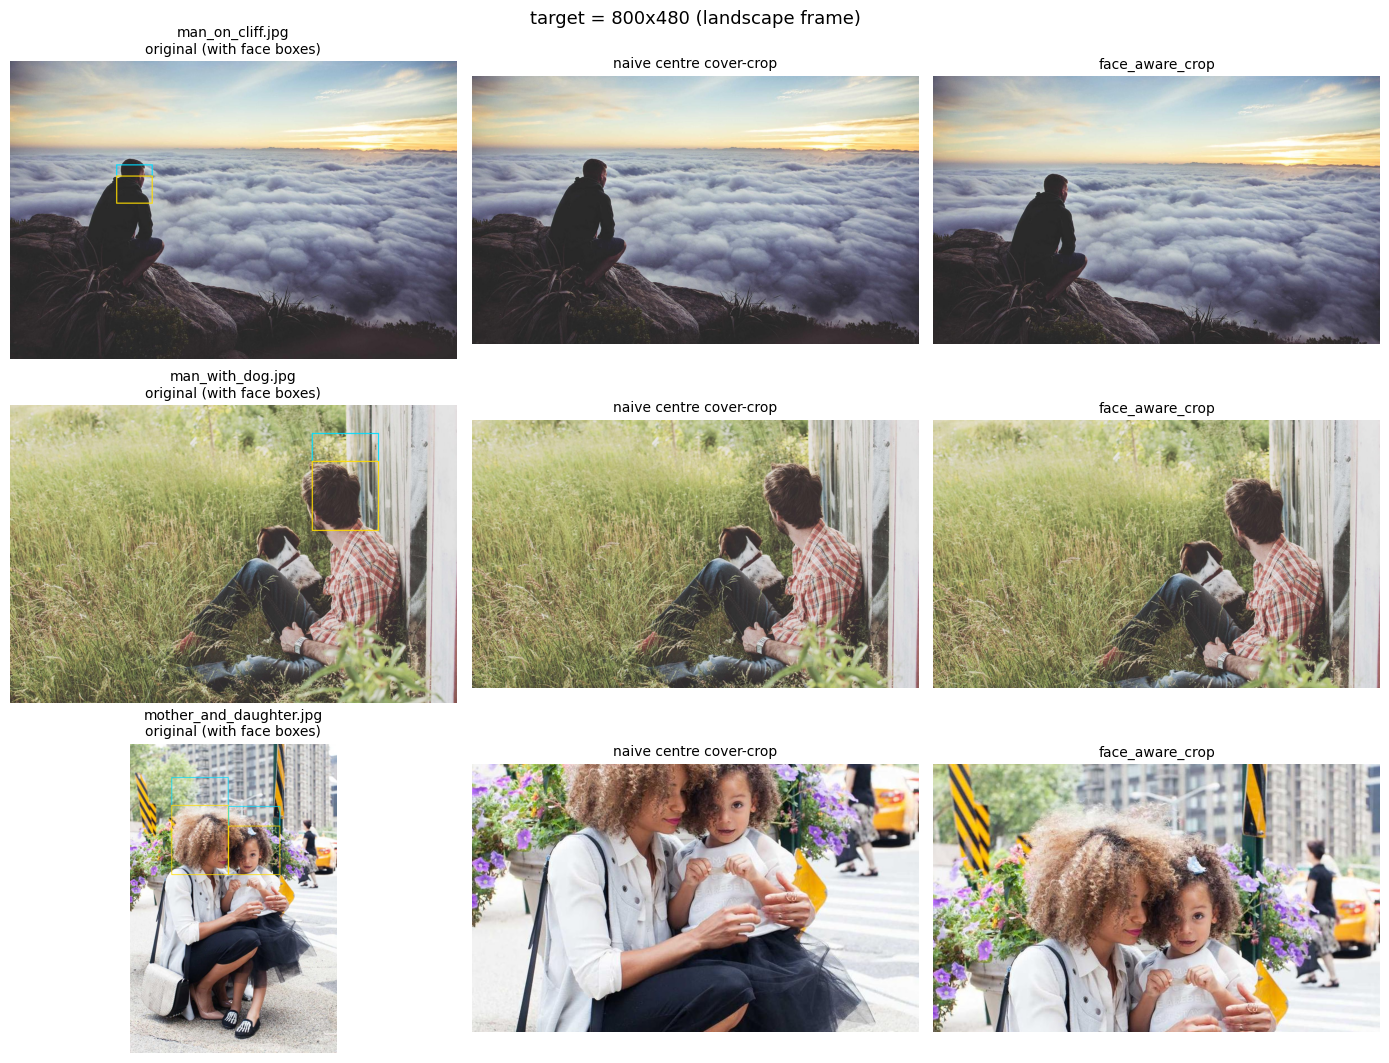

In [4]:
def render_section(target_w, target_h, label):
    rows = []
    for asset in with_faces:
        img = open_image(asset)
        faces = image_faces(asset)
        annotated = draw_face_boxes(img, faces)
        centre = center_crop(img, target_w, target_h)
        smart = face_aware_crop(img, target_w, target_h, faces)
        rows.append((asset["originalFileName"], annotated, centre, smart))

    fig, axes = plt.subplots(len(rows), 3, figsize=(14, 3.6 * len(rows)))
    if len(rows) == 1:
        axes = [axes]
    fig.suptitle(f"target = {target_w}x{target_h} ({label})", fontsize=13)
    titles = ["original (with face boxes)", "naive centre cover-crop", "face_aware_crop"]
    for i, (name, annotated, centre, smart) in enumerate(rows):
        for j, (img_panel, base_title) in enumerate(
            zip([annotated, centre, smart], titles, strict=True)
        ):
            ax = axes[i][j]
            ax.imshow(img_panel)
            t = f"{name}\n{base_title}" if j == 0 else base_title
            ax.set_title(t, fontsize=10)
            ax.axis("off")
    plt.tight_layout()
    plt.show()


render_section(*LANDSCAPE, "landscape frame")

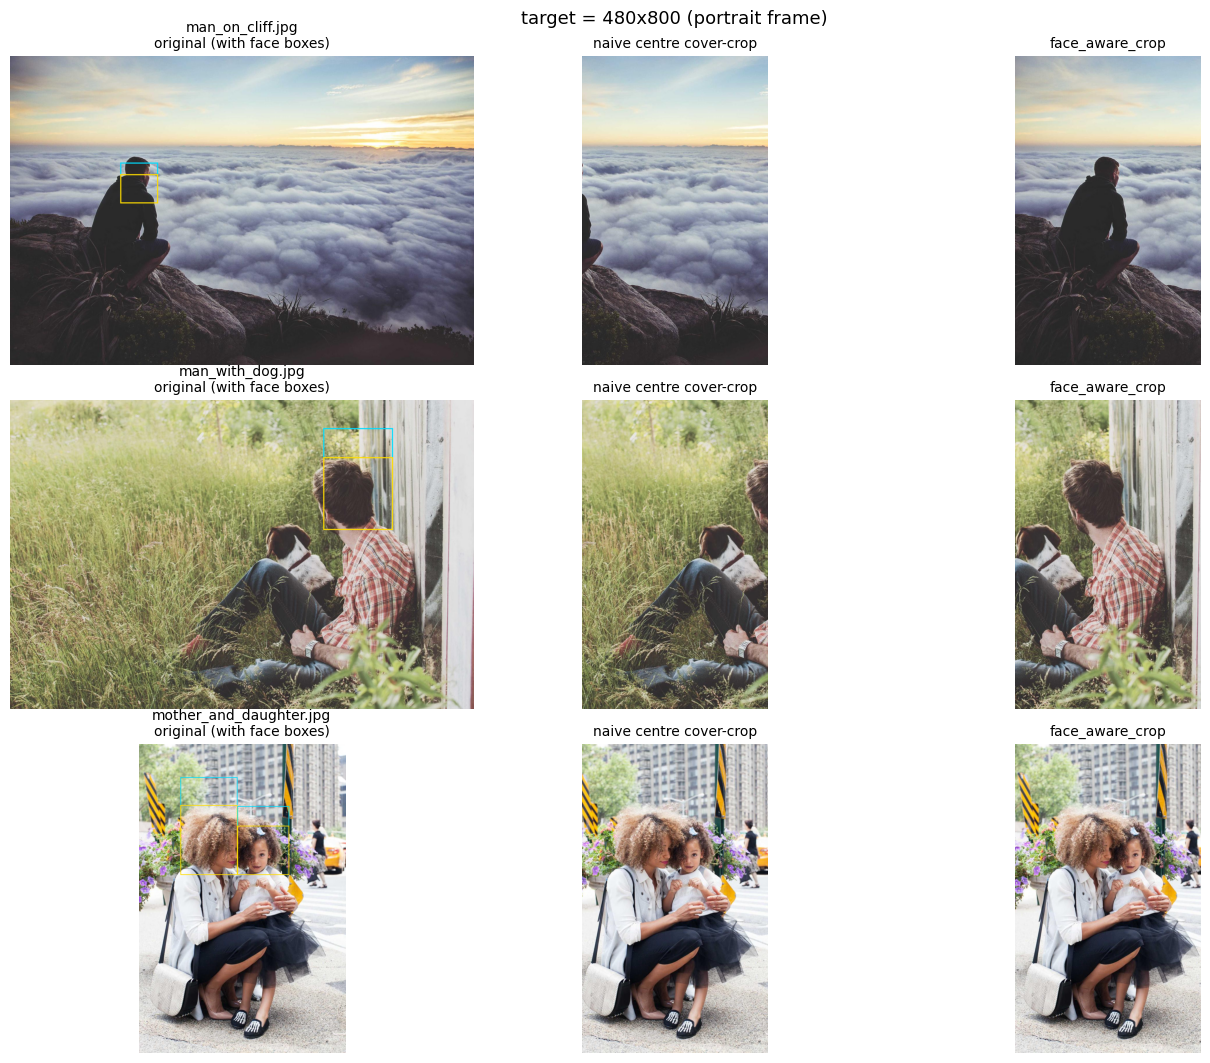

In [5]:
render_section(*PORTRAIT, "portrait frame")

## Reading the comparison

- **Cyan boxes** are the head-extended face regions the algorithm uses to
  position the crop. The extension (`HEAD_EXTENSION`) accounts for face boxes
  ending at the hairline, so the joint-span midpoint lands closer to the eyes.
- **Yellow boxes** are the raw bounding boxes from the source.
- For portrait sources on a landscape target, the face centre sits at the
  **top third** of the crop window, not the middle. That keeps the eyes on
  the upper-third line and leaves room for the body below.
- The naive centre cover-crop column shows what you'd get without face
  awareness. It's the worst case, the column to compare against.